# Numerical prototype for degenerate lake equations and vanishing viscosity# Numerical prototype for for the degenerate lake equations.

The project separates three main components:

1. **Inviscid lake equations** in vorticity-stream formulation.
2. **Viscous lake equations** in velocity formulation.
3. **Vanishing-viscosity comparison** in the weighted velocity norm \(L^2_b\).

The code is modular. Most implementation details are stored in the Python package:

```text
lake/
├── config.py
├── grid.py
├── operators.py
├── elliptic.py
├── inviscid.py
├── projection.py
├── viscous.py
├── diagnostics.py
└── plotting.py




# Cellule 2 — Markdown : modèle mathématique


## Mathematical setting

The computational domain is the unit disk:

$$
\Omega = \{(x,y): x^2+y^2<1\}.
$$

The boundary is:

$$
\partial\Omega = \{(x,y): x^2+y^2=1\}.
$$

The bathymetry is chosen as:

$$
b(x,y) = (1-r^2)^\alpha,
\qquad r=\sqrt{x^2+y^2},
\qquad \alpha=0.4.
$$

Near the boundary,

$$
1-r^2=(1-r)(1+r)\sim 2\,\mathrm{dist}(x,\partial\Omega),
$$

so

$$
b(x,y)\sim \mathrm{dist}(x,\partial\Omega)^\alpha.
$$

Thus $ b\to 0$ at the boundary.

---

## Inviscid lake equations

The inviscid problem is solved in vorticity formulation:

$$
\partial_t\omega + u\cdot\nabla\omega = 0.
$$

The velocity is reconstructed from the stream function:

$$
\operatorname{div}\left(\frac1b\nabla\psi\right)=b\omega,
$$

$$
u = \frac1b\nabla^\perp\psi.
$$

We use the convention:

$$
\nabla^\perp\psi=(-\partial_y\psi,\partial_x\psi),
$$

and

$$
\operatorname{curl}u=\partial_xu_y-\partial_yu_x.
$$

Therefore,

$$
\omega=\frac{\operatorname{curl}u}{b}.
$$

The operator

$$
\operatorname{div}\left(\frac1b\nabla\psi\right)
$$

is singular because $1/b \to +\infty $ near the boundary.

---

## Viscous lake equations

The viscous problem is treated in velocity formulation:

$$
\partial_t(bu_\mu)
+\operatorname{div}(b u_\mu\otimes u_\mu)
-2\mu \operatorname{div}\left(bD(u_\mu)+b\operatorname{div}(u_\mu)I\right)
+b\nabla p_\mu = 0,
$$

with

$$
\operatorname{div}(bu_\mu)=0.
$$

The projection step uses the degenerate operator:

$$
\operatorname{div}(b\nabla\phi)=\operatorname{div}(bu_\star),
$$

then

$$
u^{n+1}=u_\star-\nabla\phi.
$$

This operator is degenerate because $b\to 0$ near the boundary.

---

## Vanishing-viscosity comparison

The final comparison is performed only at the velocity level:

$$
\|u_\mu-u\|_{L^2_b}
=
\left(
\int_\Omega b |u_\mu-u|^2\,dx
\right)^{1/2}.
$$

In this prototype, the observed error also contains numerical effects:

- grid error;
- time-step error;
- elliptic solver error;
- projection consistency error;
- boundary-mask geometry error.

In [32]:

from pathlib import Path
import numpy as n
import sys
import matplotlib.pyplot as plt

# Ensure that the project root is importable.
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lake.config import default_config, print_config_summary
from lake.grid import create_grid, print_grid_summary
from lake.operators import build_initial_fields, print_initial_diagnostics
from lake.elliptic import (
    assemble_singular_matrix,
    print_singular_matrix_summary,
    reconstruct_from_vorticity,
    reconstruction_diagnostics,
    print_reconstruction_diagnostics,
    reconstruction_sign_warning,
)
from lake.projection import (
    build_projection_data,
    print_projection_matrix_summary,
)
from lake.plotting import plot_initial_data

print("Imports completed.")
import sys



Imports completed.


In [37]:
cfg = default_config()

# Notebook-friendly default parameters.
# Increase N later for better accuracy, but N=96 keeps runtime reasonable.
cfg.N = 96

cfg.T_inviscid = 0.05
cfg.T_viscous = 0.05
cfg.T_limit = 0.05

cfg.mu_plot_values = [1.0e-2, 5.0e-3]
cfg.mu_values = [1.0e-2, 5.0e-3, 2.0e-3]

cfg.CFL_inviscid = 0.5
cfg.CFL_viscous = 0.2

cfg.dt_max_inviscid = 2.0e-3
cfg.dt_max_viscous = 5.0e-4

cfg.verbose = True

print_config_summary(cfg)


Lake-equation vanishing-viscosity configuration

Grid/domain
  N                 = 96
  domain square      = [-1.0, 1.0] x [-1.0, 1.0]
  disk radius        = 1.0

Bathymetry
  alpha             = 0.4
  eps_safe          = 1e-14

Initial data
  bump_center       = (0.25, 0.0)
  bump_radius       = 0.25
  support_threshold = 0.001

Inviscid solver
  T_inviscid        = 0.05
  CFL_inviscid      = 0.5
  dt_max_inviscid   = 0.002

Viscous solver
  T_viscous         = 0.05
  CFL_viscous       = 0.2
  dt_max_viscous    = 0.0005
  mu_plot_values    = [0.01, 0.005]

Vanishing-viscosity experiment
  T_limit           = 0.05
  mu_values         = [0.01, 0.005, 0.002]
  beta refs         = [0.0, 0.5]

Projection
  use regularization = True
  eps factor         = 1.0

CG solver
  cg_rtol           = 1e-10
  cg_atol           = 1e-12
  cg_maxiter        = 5000


In [38]:
grid = create_grid(cfg)

print_grid_summary(grid, cfg)

Grid and bathymetry summary
N                         = 96
radius                    = 1.00000000e+00
dx                        = 2.10526316e-02
dy                        = 2.10526316e-02
h                         = 2.10526316e-02
active grid points         = 7080
topological boundary nodes = 268
boundary band 1h nodes     = 308
boundary band 2h nodes     = 592
boundary band 3h nodes     = 900

Bathymetry
alpha                     = 0.4
min b inside mask          = 7.73139068e-02
max b inside mask          = 9.99911351e-01

Initial stream function
support distance psi0      = 5.20619051e-01


In [39]:
fields = build_initial_fields(grid)

print_initial_diagnostics(fields)


Initial-field diagnostics
||div(bu0)||_L2                       = 2.11091897e-15
relative div(bu0)                     = 4.94954706e-17
||curl(u0)/b - omega0||_L2            = 0.00000000e+00
relative vorticity residual           = 0.00000000e+00
||omega0||_L2                         = 1.82567896e+01
support distance psi0                 = 5.20619051e-01
support distance omega0               = 4.78973951e-01
weighted kinetic energy of u0          = 4.19763487e-01
||u0||_L2_b                            = 9.16257046e-01


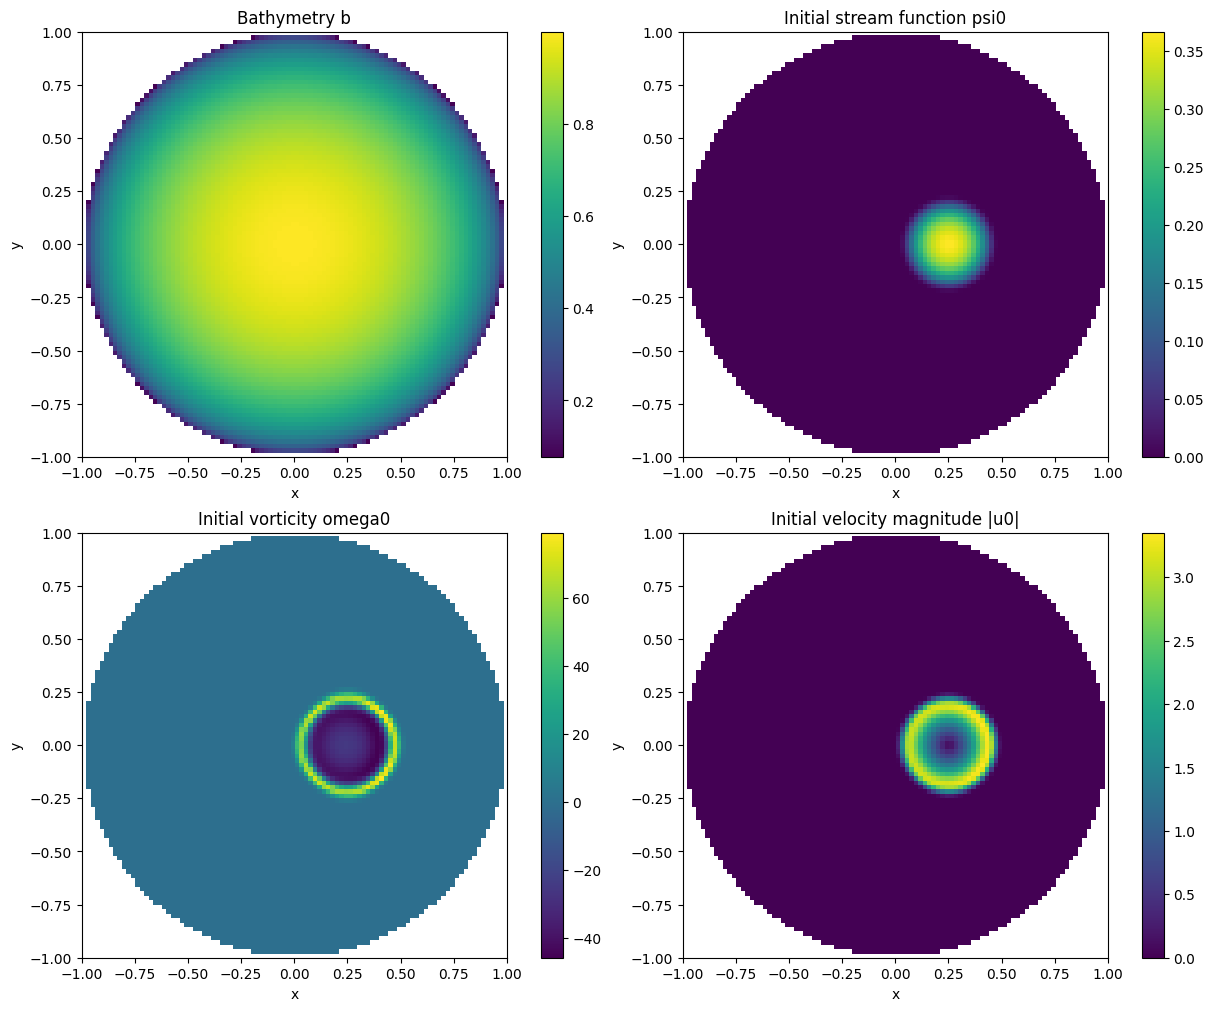

In [40]:
plot_initial_data(
    grid=grid,
    omega0=fields.omega0,
    u0=fields.u0,
)


## Initial data interpretation

The initial stream function $\psi_0$ is a compactly supported bump away from the boundary.


Therefore,

$$
bu_0=\nabla^\perp\psi_0,
$$

and one expects

$$
\operatorname{div}(bu_0)=0.
$$

The initial vorticity prototype is computed as

$$
\omega_0
=
\frac1b\operatorname{div}\left(\frac1b\nabla\psi_0\right).
$$

The local residuals printed above are finite-difference consistency diagnostics.  
The sparse elliptic reconstruction is checked next.
``

The initial velocity is defined by



In [41]:
ell_data = assemble_singular_matrix(grid)

print_singular_matrix_summary(ell_data)

Singular elliptic matrix summary
Operator: A_sing = -div((1/b) grad)
Face averaging: harmonic average for interior mask faces
Boundary treatment: first-order masked-grid Dirichlet flux
shape              = (6812, 6812)
number of unknowns = 6812
nnz                = 33692
symmetry defect    = 0.00000000e+00


In [42]:
rec0 = reconstruct_from_vorticity(
    omega=fields.omega0,
    grid=grid,
    elliptic_data=ell_data,
    cfg=cfg,
)

diag_rec0 = reconstruction_diagnostics(
    psi_reference=fields.psi0,
    u_reference=fields.u0,
    omega=fields.omega0,
    reconstruction=rec0,
    grid=grid,
)

print_reconstruction_diagnostics(diag_rec0)

if reconstruction_sign_warning(fields.psi0, rec0.psi, grid):
    print("WARNING: possible sign convention issue.")
else:
    print("Sign convention check passed.")

Singular elliptic reconstruction diagnostics
||psi_rec - psi_ref||_L2              = 1.66289109e-03
relative psi error                    = 1.93702130e-02
||u_rec - u_ref||_L2_b                = 6.05526025e-02
relative velocity error               = 6.60869160e-02
||curl(u_rec)/b - omega||_L2          = 2.94843944e+00
relative vorticity residual           = 1.61498243e-01
||div(bu_rec)||_L2                    = 1.57379337e-15
relative div(bu_rec)                  = 3.80703907e-17
elliptic residual                     = 8.17788407e-08
relative elliptic residual            = 9.87246497e-11
CG info                               = 0
CG iterations                         = 389
Sign convention check passed.


In [44]:
proj_data = build_projection_data(grid, cfg)
print_projection_matrix_summary(proj_data)

Degenerate projection matrix summary
Operator: A_proj = -div(b_proj grad)
Face averaging: arithmetic average of b_proj
Boundary treatment: first-order masked-grid Dirichlet flux
epsilon_proj      = 4.43213296e-04
shape             = (6812, 6812)
number unknowns   = 6812
nnz               = 33692
symmetry defect   = 0.00000000e+00
Note: b_proj = b + epsilon_proj.
      Projection is stabilized but approximate.


## End of Part 1

At this stage, the notebook has constructed:
- the masked Cartesian disk grid;
- the degenerate bathymetry $b$;
- the initial stream function $\psi_0$;
- the initial velocity $u_0$;
- the initial vorticity prototype $\omega_0$;
- the singular elliptic operator for inviscid reconstruction;
- the degenerate projection operator for the viscous solver.

Next parts:

1. Run the inviscid vorticity solver.
2. Run the viscous velocity solver.
3. Compare $u_\mu$ and $u$ in the weighted norm $L^2_b$.




## Part 2 — Inviscid lake solver

We now solve the inviscid lake equations in vorticity formulation:

$$
\partial_t \omega + u\cdot\nabla\omega = 0.
$$

At each time step, the velocity is reconstructed from the singular elliptic problem:

$$
\operatorname{div}\left(\frac1b\nabla\psi\right)=b\omega,
$$

with

$$
u=\frac1b\nabla^\perp\psi.
$$

The numerical solver uses:

1. sparse elliptic reconstruction for $\psi$;
2. velocity reconstruction from $\psi$;
3. semi-Lagrangian transport for $\omega$;
4. monitoring of $\mathrm{div}(bu)$, vorticity residuals, support distance, and elliptic residuals.

The semi-Lagrangian method is stable and convenient, but it is not exactly conservative and may introduce interpolation diffusion.

In [45]:
from lake.inviscid import (
    run_inviscid_solver,
    print_inviscid_summary,
)

from lake.plotting import (
    plot_inviscid_solution,
    plot_inviscid_diagnostics,
)

print("Inviscid solver imports completed.")

Inviscid solver imports completed.


In [46]:
result_inv = run_inviscid_solver(
    omega_initial=fields.omega0,
    grid=grid,
    elliptic_data=ell_data,
    cfg=cfg,
    T=cfg.T_inviscid,
    CFL=cfg.CFL_inviscid,
    dt_max=cfg.dt_max_inviscid,
)

print_inviscid_summary(result_inv)

Inviscid solver summary
final time                         = 5.00000000e-02
number of stored steps             = 26
final min omega                    = -3.96483938e+01
final max omega                    = 6.19677597e+01
final ||omega||_Linf               = 6.19677597e+01
final support distance             = 4.54862847e-01
final ||div(bu)||_L2               = 1.73364298e-15
final relative div(bu)             = 5.06503013e-17
final ||curl(u)/b - omega||_L2     = 5.10908365e+00
final elliptic residual            = 6.18717910e-08
average CG iterations              = 402.115
max CFL ratio                      = 3.04547536e-01


In [47]:
omega_inv_final = result_inv.omega_final
psi_inv_final = result_inv.psi_final
u_inv_final = result_inv.u_final
diag_inv = result_inv.diagnostics

print("Final inviscid fields extracted:")
print(f"omega_inv_final shape = {omega_inv_final.shape}")
print(f"psi_inv_final shape   = {psi_inv_final.shape}")
print(f"u_inv_final shape     = {u_inv_final.shape}")

Final inviscid fields extracted:
omega_inv_final shape = (96, 96)
psi_inv_final shape   = (96, 96)
u_inv_final shape     = (96, 96, 2)


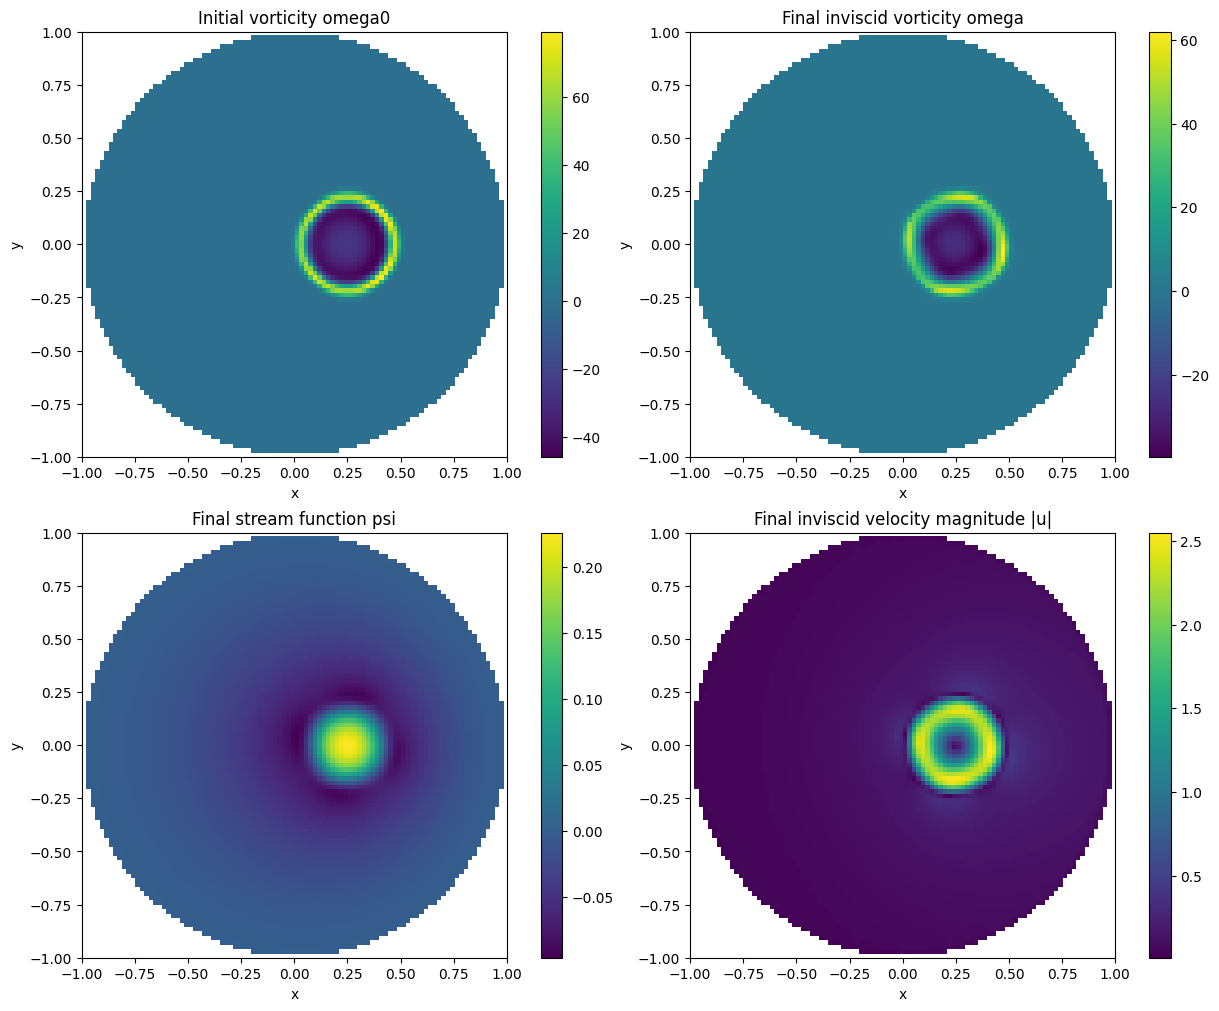

In [12]:
plot_inviscid_solution(
    omega_initial=fields.omega0,
    omega_final=omega_inv_final,
    psi_final=psi_inv_final,
    u_final=u_inv_final,
    grid=grid,
)

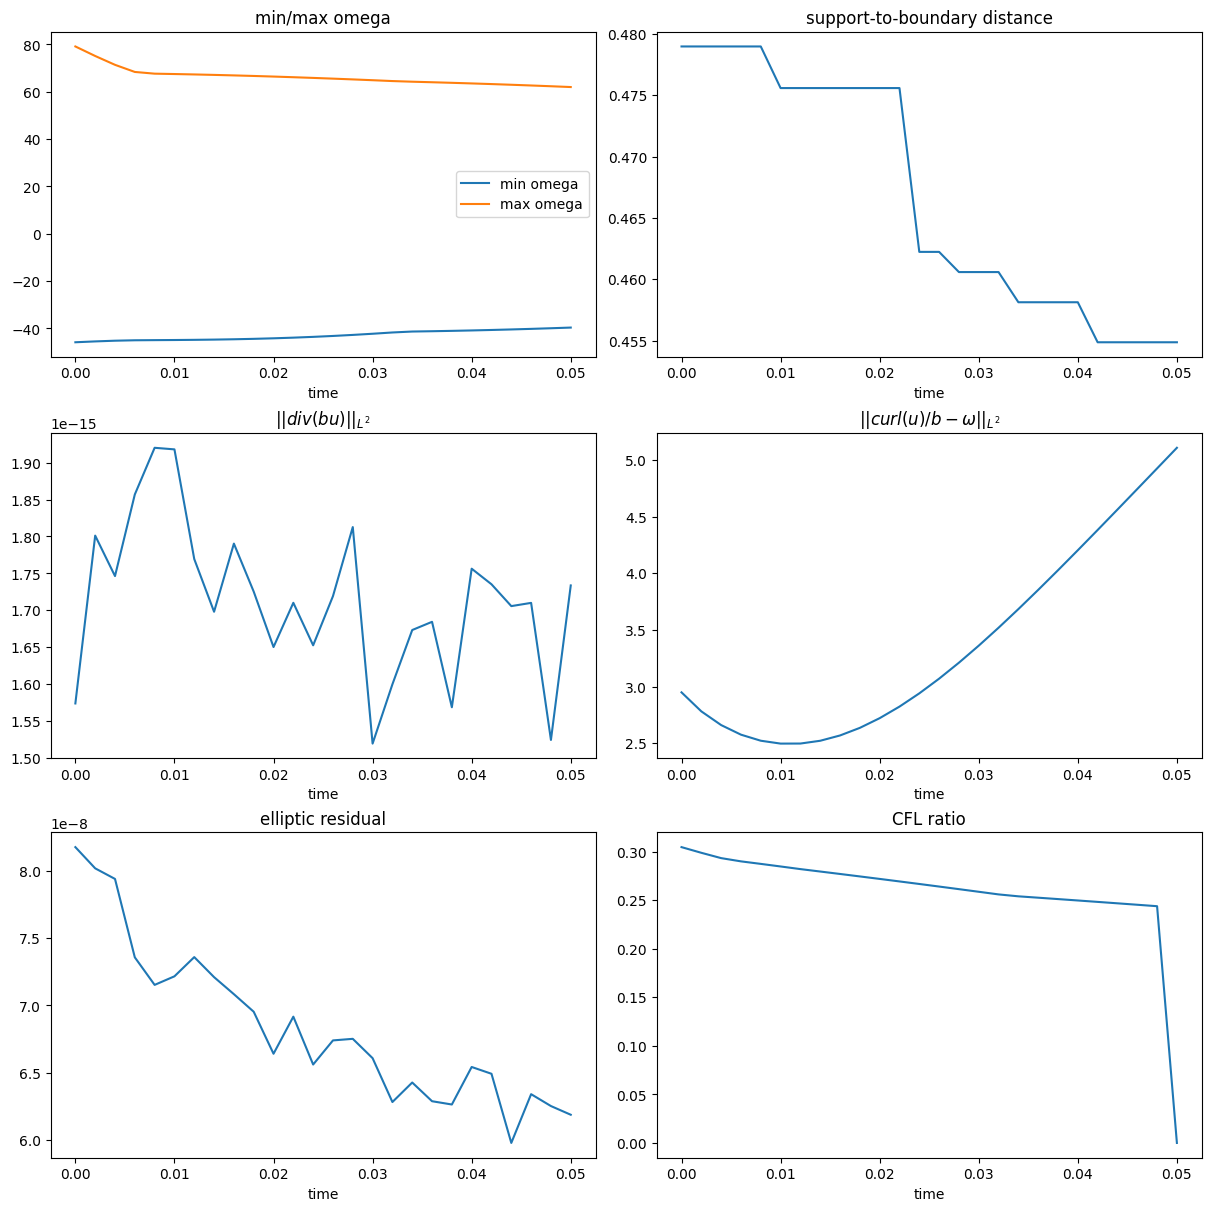

In [48]:
plot_inviscid_diagnostics(diag_inv)

## Inviscid solver interpretation

The inviscid solver evolves the scalar vorticity \(\omega\), not the velocity directly.

The velocity field is reconstructed at every time step by solving:

$$
\operatorname{div}\left(\frac1b\nabla\psi\right)=b\omega.
$$

This elliptic operator is singular near the boundary because \(b\to0\), hence:

$$
\frac1b\to+\infty.
$$

The numerical reconstruction preserves this singular coefficient in divergence form.

The main diagnostics are:

- \(\|\operatorname{div}(bu)\|_{L^2}\), which checks weighted incompressibility;
- \(\|\operatorname{curl}(u)/b-\omega\|_{L^2}\), which compares reconstructed velocity and transported vorticity;
- the elliptic residual, which checks the sparse solve;
- the support-to-boundary distance, which checks whether vorticity remains away from the degenerate boundary;
- the CFL ratio \(\max |u|\Delta t/h\), which monitors transport resolution.

A nonzero value of

$$
\|\operatorname{curl}(u)/b-\omega\|_{L^2}
$$

is expected because \(\omega\) is transported by interpolation, while \(\operatorname{curl}(u)\) is recomputed with local finite differences from the reconstructed velocity.

In [49]:
import numpy as np
print("=" * 80)
print("Targeted inviscid diagnostics")
print("=" * 80)

print(f"Final time                         = {diag_inv['time'][-1]:.8e}")
print(f"Final min omega                    = {diag_inv['min_omega'][-1]:.8e}")
print(f"Final max omega                    = {diag_inv['max_omega'][-1]:.8e}")
print(f"Final ||omega||_Linf               = {diag_inv['omega_linf'][-1]:.8e}")
print(f"Final support distance             = {diag_inv['support_distance'][-1]:.8e}")
print(f"Final ||div(bu)||_L2               = {diag_inv['divbu_l2'][-1]:.8e}")
print(f"Final relative div(bu)             = {diag_inv['relative_divbu'][-1]:.8e}")
print(f"Final ||curl(u)/b - omega||_L2     = {diag_inv['vorticity_residual_l2'][-1]:.8e}")
print(f"Final elliptic residual            = {diag_inv['elliptic_residual'][-1]:.8e}")
print(f"Average CG iterations              = {np.mean(diag_inv['cg_iterations']):.3f}")
print(f"Maximum CFL ratio                  = {np.max(diag_inv['cfl_ratio']):.8e}")

print("=" * 80)

Targeted inviscid diagnostics
Final time                         = 5.00000000e-02
Final min omega                    = -3.96483938e+01
Final max omega                    = 6.19677597e+01
Final ||omega||_Linf               = 6.19677597e+01
Final support distance             = 4.54862847e-01
Final ||div(bu)||_L2               = 1.73364298e-15
Final relative div(bu)             = 5.06503013e-17
Final ||curl(u)/b - omega||_L2     = 5.10908365e+00
Final elliptic residual            = 6.18717910e-08
Average CG iterations              = 402.115
Maximum CFL ratio                  = 3.04547536e-01


## Part 3 — Viscous lake solver

We now solve a prototype viscous lake equation in **velocity formulation**.

$$
\operatorname{div}(bu_\mu)=0.
$$

Here,

$$
D(u_\mu)=\frac12\left(\nabla u_\mu+\nabla u_\mu^T\right)
$$

is the symmetric part of the velocity gradient.

---

### Boundary condition in the continuous theory

In the continuous viscous theory, the boundary conditions are Navier-type:

$$
bu_\mu\cdot n=0,
$$

and

$$
2b\left(D(u_\mu)\cdot n+\operatorname{div}(u_\mu)n\right)\cdot \tau
+\eta_\mu b(u_\mu\cdot\tau)=0.
$$

In this notebook, these boundary conditions are **not imposed exactly**.  
The computation is performed on a masked Cartesian grid, so boundary effects are only approximated and monitored through diagnostics.

---

### Numerical scheme

The numerical method is a predictor-projection prototype.

First, a provisional velocity $u_\star$ is computed explicitly:

$$
u_\star
=
u^n
-\Delta t\,\frac{\operatorname{div}(b u^n\otimes u^n)}{b_{\rm safe}}
+\Delta t\,\mu
\frac{
2\operatorname{div}\left(bD(u^n)+b\operatorname{div}(u^n)I\right)
}{b_{\rm safe}}.
$$

Then a weighted projection is applied:

$$
\operatorname{div}(b\nabla\phi)
=
\operatorname{div}(bu_\star),
$$

and the corrected velocity is

$$
u^{n+1}=u_\star-\nabla\phi.
$$

---

### Degenerate projection

The projection operator

$$
\operatorname{div}(b\nabla\phi)
$$

is degenerate because

$$
b\to 0
\quad\text{near}\quad
\partial\Omega.
$$

For numerical stability, the prototype uses the stabilized coefficient

$$
b_{\rm proj}=b+\varepsilon_{\rm proj},
\qquad
\varepsilon_{\rm proj}=h^2.
$$

This improves conditioning, but the projection is then only approximate.  
Therefore, the diagnostics must monitor

$$
\|\operatorname{div}(bu_\mu)\|_{L^2},
$$

the projection defect, and the projection solver residual.

The continuous viscous lake model is

$$
\partial_t(bu_\mu)
+\operatorname{div}(b u_\mu\otimes u_\mu)
-2\mu\operatorname{div}\left(bD(u_\mu)+b\operatorname{div}(u_\mu)I\right)
+b\nabla p_\mu
=0,
$$



In [15]:
from lake.viscous import (
    print_viscous_summary,    run_viscous_solver,
)

from lake.plotting import (
    plot_viscous_solution,
    plot_viscous_diagnostics,
    plot_multiple_viscous_histories,
)

print("Viscous solver imports completed.")




Viscous solver imports completed.


In [50]:
# Viscosities used for the demonstration.
mu_plot_values = cfg.mu_plot_values

# Common final time for the viscous demonstration.
T_viscous = cfg.T_viscous

print("Viscous simulation parameters")
print("=" * 80)
print(f"T_viscous      = {T_viscous}")
print(f"mu_plot_values = {mu_plot_values}")
print(f"CFL_viscous    = {cfg.CFL_viscous}")
print(f"dt_max_viscous = {cfg.dt_max_viscous}")
print("=" * 80)

Viscous simulation parameters
T_viscous      = 0.05
mu_plot_values = [0.01, 0.005]
CFL_viscous    = 0.2
dt_max_viscous = 0.0005


In [52]:
# Viscosities used for the demonstration.
mu_plot_values = cfg.mu_plot_values

# Common final time for the viscous demonstration.
T_viscous = cfg.T_viscous

print("Viscous simulation parameters")
print("=" * 80)
print(f"T_viscous      = {T_viscous}")
print(f"mu_plot_values = {mu_plot_values}")
print(f"CFL_viscous    = {cfg.CFL_viscous}")
print(f"dt_max_viscous = {cfg.dt_max_viscous}")
print("=" * 80)

Viscous simulation parameters
T_viscous      = 0.05
mu_plot_values = [0.01, 0.005]
CFL_viscous    = 0.2
dt_max_viscous = 0.0005


In [54]:
viscous_results = {}

for mu in mu_plot_values:
    print()
    print("=" * 80)
    print(f"Running viscous solver for mu = {mu:.4e}")
    print("=" * 80)

    result_visc = run_viscous_solver(
        u_initial=fields.u0,
        mu=float(mu),
        grid=grid,
        projection_data=proj_data,
        cfg=cfg,
        T=T_viscous,
        CFL=cfg.CFL_viscous,
        dt_max=cfg.dt_max_viscous,
        project_initial=True,
    )

    print_viscous_summary(result_visc)

    viscous_results[float(mu)] = result_visc


Running viscous solver for mu = 1.0000e-02
Viscous solver summary
final time                         = 5.00000000e-02
number of time steps               = 100
mu                                 = 1.00000000e-02
initial stored energy              = 4.18321160e-01
final weighted energy              = 3.23164437e-01
final ||div(bu)||_L2               = 1.01329790e-01
final relative div(bu)             = 2.70711217e-03
final projection defect after      = 1.01329790e-01
final projection solver residual   = 6.88629775e-10
average projection CG iterations   = 361.090
max CFL ratio                      = 7.93862954e-02
boundary no-penetration max        = 2.24680059e-03

Running viscous solver for mu = 5.0000e-03
Viscous solver summary
final time                         = 5.00000000e-02
number of time steps               = 100
mu                                 = 5.00000000e-03
initial stored energy              = 4.19041918e-01
final weighted energy              = 3.67361176e-01
final ||div

In [60]:
# Select one viscosity for detailed visualization.
mu_selected = float(mu_plot_values[0])

result_visc_selected = viscous_results[mu_selected]

u_mu_final = result_visc_selected.u_final
p_mu_final = result_visc_selected.p_final
diag_visc = result_visc_selected.diagnostics

print("Selected viscous result")
print("=" * 80)
print(f"mu_selected = {mu_selected:.4e}")
print(f"u_mu_final shape = {u_mu_final.shape}")
print(f"p_mu_final shape = {p_mu_final.shape}")
print("=" * 80)


Selected viscous result
mu_selected = 1.0000e-02
u_mu_final shape = (96, 96, 2)
p_mu_final shape = (96, 96)


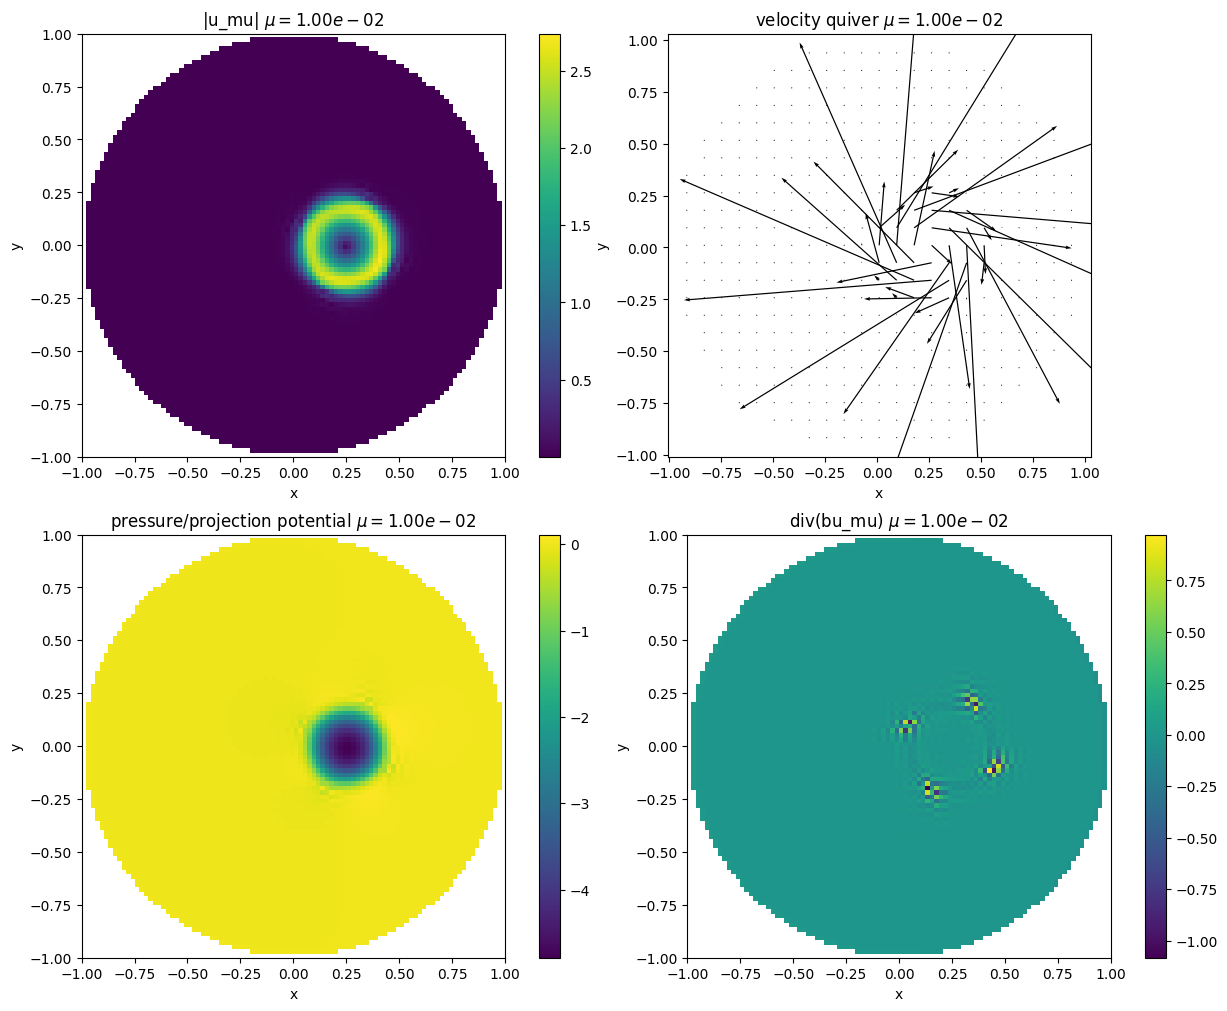

In [62]:
plot_viscous_solution(
    u_mu=u_mu_final,
    p_mu=p_mu_final,
    grid=grid,
    title_suffix=rf"$\mu={mu_selected:.2e}$",
)


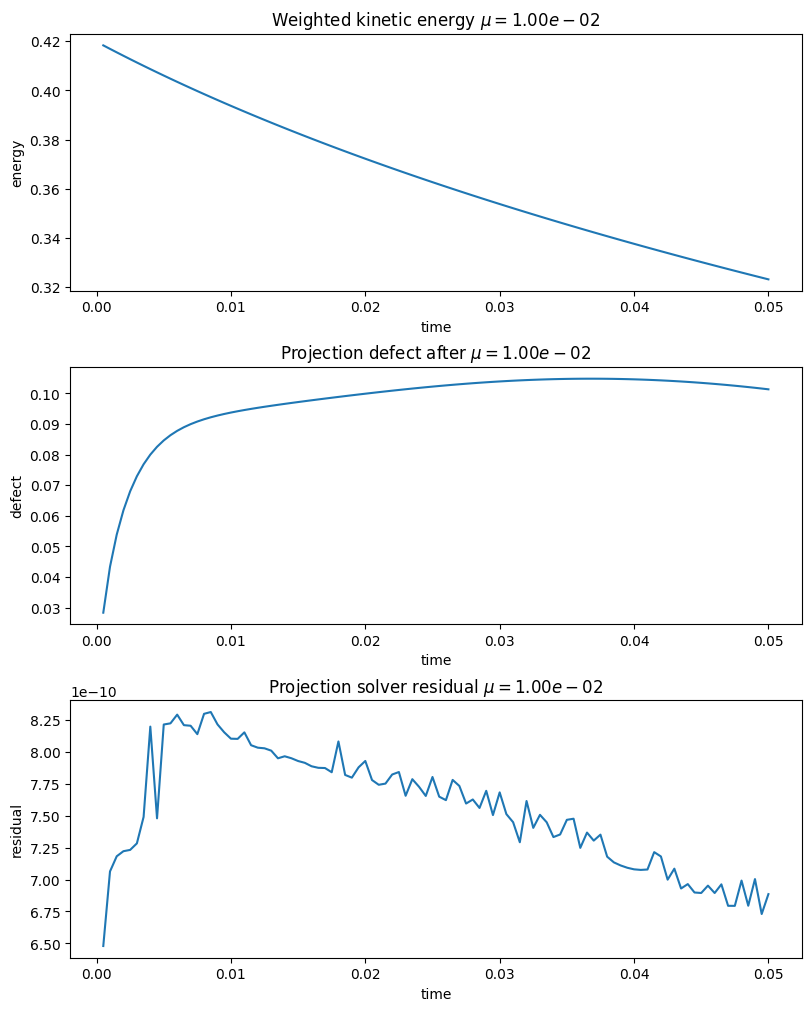

In [63]:
plot_viscous_diagnostics(
    diagnostics=diag_visc,
    title_suffix=rf"$\mu={mu_selected:.2e}$",
)

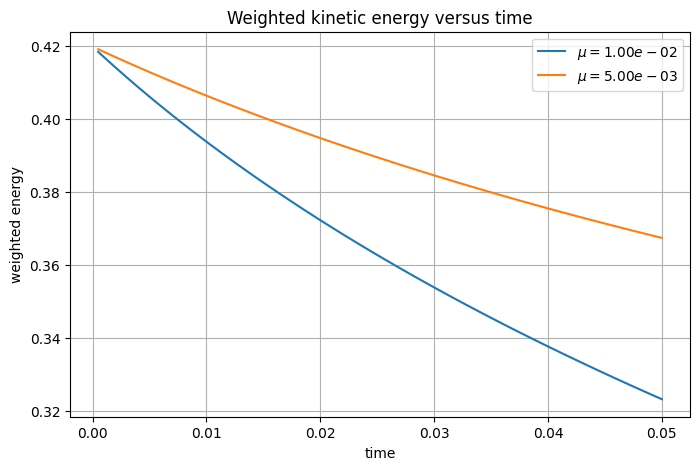

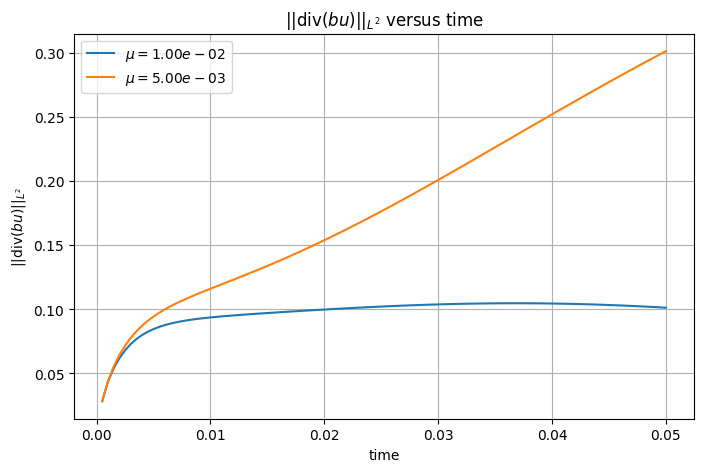

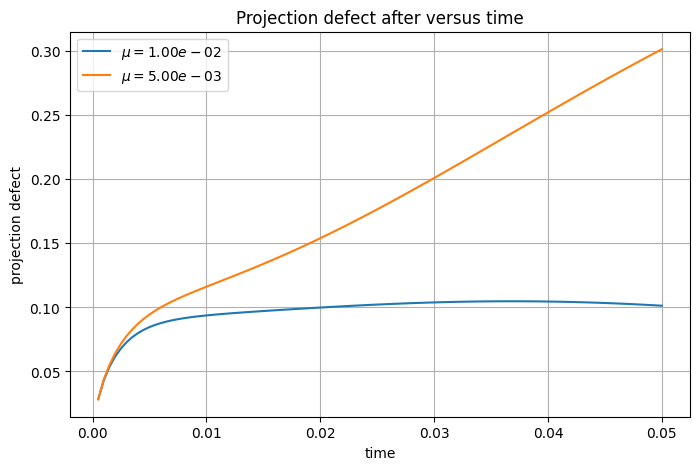

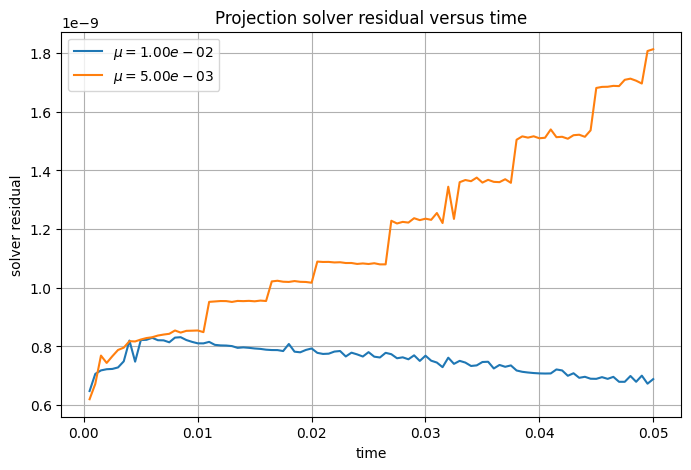

In [64]:
plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="weighted_energy",
    title="Weighted kinetic energy versus time",
    ylabel="weighted energy",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="divbu_l2",
    title=r"$||\operatorname{div}(bu)||_{L^2}$ versus time",
    ylabel=r"$||\operatorname{div}(bu)||_{L^2}$",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="projection_defect_after",
    title="Projection defect after versus time",
    ylabel="projection defect",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="projection_solver_residual",
    title="Projection solver residual versus time",
    ylabel="solver residual",
)

For smaller viscosity, the projection defect increases in this prototype.For smaller viscosity, the defect is controlled below the velocity error.


In [65]:
print("=" * 80)
print(f"Targeted viscous diagnostics for mu = {mu_selected:.4e}")
print("=" * 80)

d = diag_visc

print(f"Final time                         = {d['time'][-1]:.8e}")
print(f"Number of time steps               = {len(d['time'])}")

if "weighted_energy" in d:
    print(f"Initial stored energy              = {d['weighted_energy'][0]:.8e}")
    print(f"Final weighted energy              = {d['weighted_energy'][-1]:.8e}")

if "divbu_l2" in d:
    print(f"Final ||div(bu)||_L2               = {d['divbu_l2'][-1]:.8e}")

if "relative_divbu" in d:
    print(f"Final relative div(bu)             = {d['relative_divbu'][-1]:.8e}")

if "projection_defect_after" in d:
    print(f"Final projection defect after      = {d['projection_defect_after'][-1]:.8e}")

if "projection_solver_residual" in d:
    print(f"Final projection solver residual   = {d['projection_solver_residual'][-1]:.8e}")

if "projection_cg_iterations" in d:
    print(f"Average projection CG iterations   = {np.mean(d['projection_cg_iterations']):.3f}")

if "cfl_ratio" in d:
    print(f"Maximum CFL ratio                  = {np.max(d['cfl_ratio']):.8e}")

if "boundary_no_penetration_max" in d:
    print(f"Boundary no-penetration max        = {d['boundary_no_penetration_max'][-1]:.8e}")

print("=" * 80)

Targeted viscous diagnostics for mu = 1.0000e-02
Final time                         = 5.00000000e-02
Number of time steps               = 100
Initial stored energy              = 4.18321160e-01
Final weighted energy              = 3.23164437e-01
Final ||div(bu)||_L2               = 1.01329790e-01
Final relative div(bu)             = 2.70711217e-03
Final projection defect after      = 1.01329790e-01
Final projection solver residual   = 6.88629775e-10
Average projection CG iterations   = 361.090
Maximum CFL ratio                  = 7.93862954e-02
Boundary no-penetration max        = 2.24680059e-03


## Viscous solver interpretation.

This is different from the inviscid solver, which evolves vorticity.

The viscous update includes:

1. a conservative advection-like term:

$$
\operatorname{div}(bu\otimes u),
$$

2. a viscous diffusion-like term:

$$
2\mu\operatorname{div}(bD(u)+b\operatorname{div}(u)I),
$$

3. a weighted projection step enforcing approximately:

$$
\operatorname{div}(bu)=0.
$$

The projection solves a degenerate elliptic problem:

$$
\operatorname{div}(b\nabla\phi)=\operatorname{div}(bu_\star).
$$

In the prototype, a stabilized coefficient is used:

$$
b_{\rm proj}=b+\varepsilon_{\rm proj}.
$$

Therefore the projection is not exact, and the quantity

$$
\|\operatorname{div}(bu_\mu)\|_{L^2}
$$

must be monitored carefully.

The continuous Navier slip-with-friction boundary condition is not exactly imposed on the masked Cartesian grid. The boundary no-penetration diagnostic is therefore only a numerical indicator.



## End of Part 3

The main objects now available are:

```python
viscous_results
mu_plot_values
u_mu_final
p_mu_final
diag_visc



## Part 4 — Vanishing-viscosity comparison

We now compare the viscous velocity $u_\mu$ with the inviscid velocity $u$.

The comparison is performed **only at the velocity level**, using the weighted norm

$$
\lVert u_\mu-u\rVert_{L^2_b}
=
\left(
\int_\Omega b |u_\mu-u|^2\,dx
\right)^{1/2}.
$$

In the discrete masked-grid setting, this becomes

$$
\|u_\mu-u\|_{L^2_b}
=
\left(
\sum_{\Omega_h} b_{ij}|u_{\mu,ij}-u_{ij}|^2\,dx\,dy
\right)^{1/2}.
$$

The inviscid reference velocity \(u\) is obtained from the vorticity solver, while \(u_\mu\) is obtained from the viscous velocity solver.

We do **not** compare vorticity between the viscous and inviscid systems.

The formal theoretical reference rate is

$$
O\left(\mu^{(1-\beta)/2}\right),
$$

under assumptions including the Navier friction scaling

$$
0\leq \eta_\mu \leq \eta \mu^{-\beta},
\qquad \beta<1.
$$

In this masked Cartesian prototype, this rate should be interpreted qualitatively unless the following numerical errors are controlled:

- spatial discretization error;
- time discretization error;
- elliptic reconstruction error;
- projection consistency error;
- boundary-mask geometry error;
- stabilization error from \(b_{\rm proj}=b+\varepsilon_{\rm proj}\).

In [66]:
from lake.diagnostics import (
    weighted_l2b_velocity_error,
    relative_weighted_l2b_velocity_error,
    build_vanishing_viscosity_table,
    print_vanishing_viscosity_table,
)

from lake.plotting import (
    plot_vanishing_errors,
    plot_error_budget,
    plot_vanishing_field_comparison,
    plot_multiple_viscous_histories,
)

print("Vanishing-viscosity imports completed.")


Vanishing-viscosity imports completed.


In [67]:
print("Objects available for vanishing-viscosity comparison")
print("=" * 80)

print(f"u_inv_final shape = {u_inv_final.shape}")
print(f"Number of viscous results = {len(viscous_results)}")
print(f"Available mu values = {list(viscous_results.keys())}")

print("=" * 80)

Objects available for vanishing-viscosity comparison
u_inv_final shape = (96, 96, 2)
Number of viscous results = 2
Available mu values = [0.01, 0.005]


In [68]:
u_mu_values = {
    float(mu): result.u_final
    for mu, result in viscous_results.items()
}

viscous_diagnostics = {
    float(mu): result.diagnostics
    for mu, result in viscous_results.items()
}

print("Prepared dictionaries for velocity comparison.")
print(f"u_mu_values keys = {list(u_mu_values.keys())}")
print(f"viscous_diagnostics keys = {list(viscous_diagnostics.keys())}")

Prepared dictionaries for velocity comparison.
u_mu_values keys = [0.01, 0.005]
viscous_diagnostics keys = [0.01, 0.005]


In [69]:
mu_values_for_comparison = sorted(
    list(u_mu_values.keys()),
    reverse=True,
)

table_vv = build_vanishing_viscosity_table(
    mu_values=mu_values_for_comparison,
    u_mu_values=u_mu_values,
    viscous_diagnostics=viscous_diagnostics,
    u_ref=u_inv_final,
    grid=grid,
)

print_vanishing_viscosity_table(table_vv)


Vanishing-viscosity velocity comparison
          mu |        err_abs |        err_rel |          divbu |       proj_def |     solver_res |    max_CFL
--------------------------------------------------------------------------------------------------------------
  1.0000e-02 |   2.835976e-01 |   3.842433e-01 |   1.013298e-01 |   1.013298e-01 |   6.886298e-10 | 7.9386e-02
  5.0000e-03 |   3.050869e-01 |   4.133590e-01 |   3.014783e-01 |   3.014783e-01 |   1.812988e-09 | 7.9517e-02
--------------------------------------------------------------------------------------------------------------
fitted absolute-error slope = -1.05375057e-01
fitted relative-error slope = -1.05375057e-01

Reference theoretical slopes:
  beta = 0.0 -> (1-beta)/2 = 0.5
  beta = 0.5 -> (1-beta)/2 = 0.25

Interpret slopes qualitatively unless h, dt, solver, projection,
boundary, and eta_mu-scaling errors are controlled.


In [70]:
print("=" * 80)
print("Direct weighted velocity errors")
print("=" * 80)

for mu in table_vv["mu"]:
    u_mu = u_mu_values[float(mu)]

    err_abs = weighted_l2b_velocity_error(
        u_mu=u_mu,
        u_ref=u_inv_final,
        grid=grid,
    )

    err_rel = relative_weighted_l2b_velocity_error(
        u_mu=u_mu,
        u_ref=u_inv_final,
        grid=grid,
    )

    print(f"mu = {mu:.4e}")
    print(f"  ||u_mu - u||_L2_b       = {err_abs:.8e}")
    print(f"  relative weighted error = {err_rel:.8e}")
    print()

print("=" * 80)

Direct weighted velocity errors
mu = 1.0000e-02
  ||u_mu - u||_L2_b       = 2.83597572e-01
  relative weighted error = 3.84243300e-01

mu = 5.0000e-03
  ||u_mu - u||_L2_b       = 3.05086901e-01
  relative weighted error = 4.13358960e-01



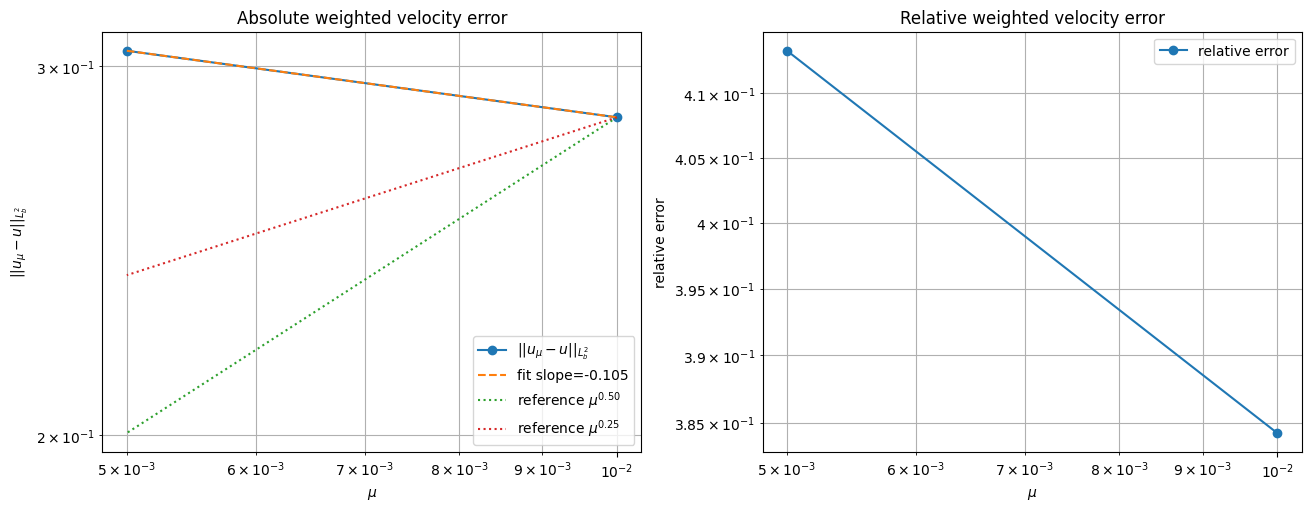

In [71]:
plot_vanishing_errors(
    table=table_vv,
    beta_reference_values=cfg.beta_reference_values,
)

The weighted velocity error does not decrease when $\mu$ is reduced from $10^{-2}$ to $5\times 10^{-3}$. 
The fitted log-log slope is negative, approximately $ -0.105 $, whereas the formal theoretical reference slopes are positive. This indicates that the current masked Cartesian prototype is not in the asymptotic vanishing-viscosity regime. The measured error is likely dominated by projection, boundary, time-step, and spatial discretization effects rather than by the viscosity error alone.

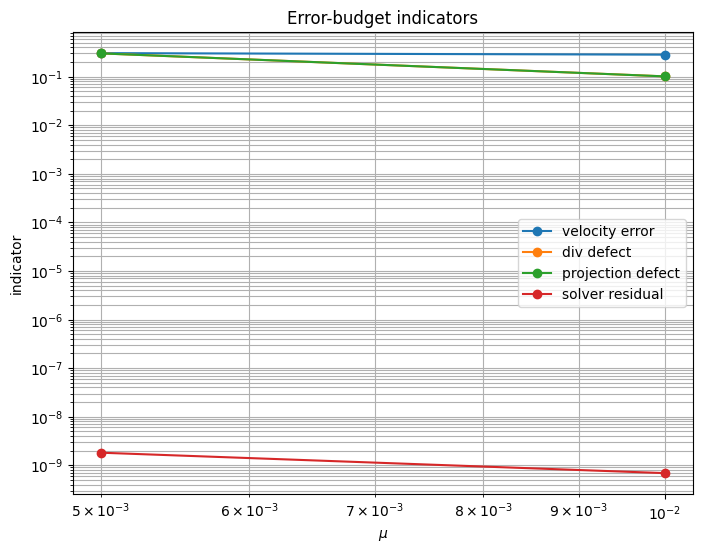

In [72]:
plot_error_budget(table_vv)

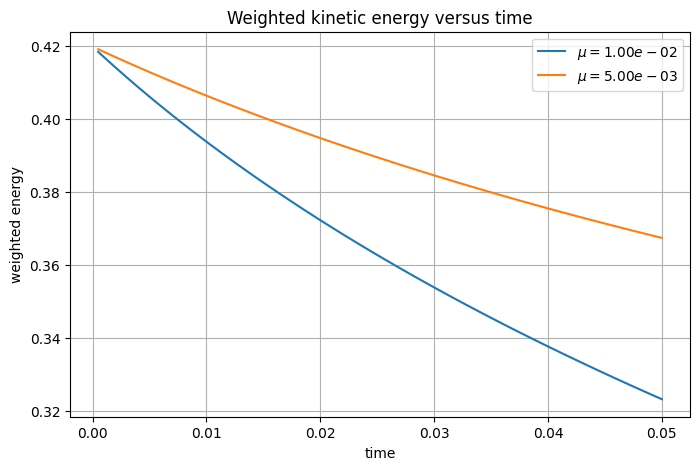

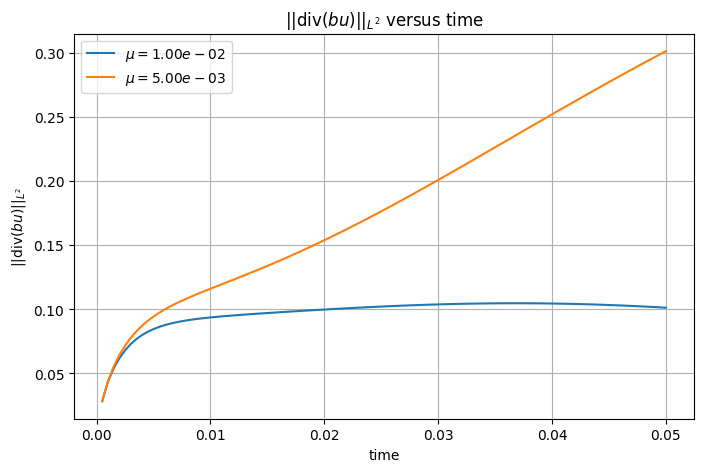

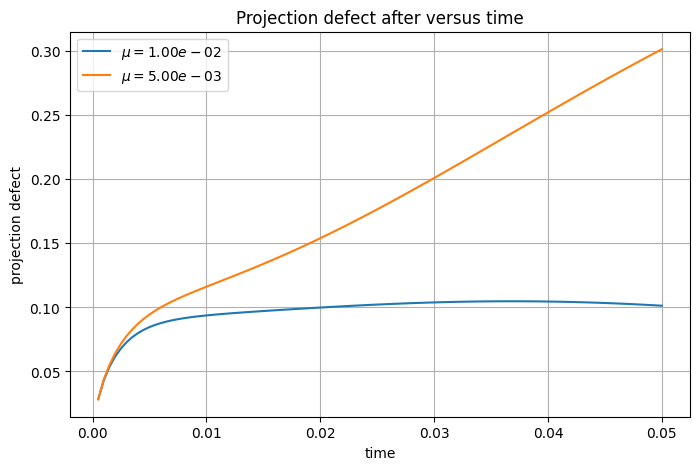

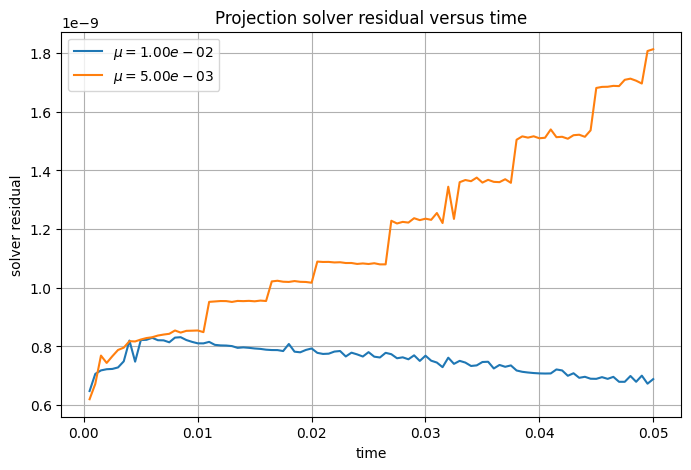

In [73]:
plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="weighted_energy",
    title="Weighted kinetic energy versus time",
    ylabel="weighted energy",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="divbu_l2",
    title=r"$||\operatorname{div}(bu)||_{L^2}$ versus time",
    ylabel=r"$||\operatorname{div}(bu)||_{L^2}$",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="projection_defect_after",
    title="Projection defect after versus time",
    ylabel="projection defect",
)

plot_multiple_viscous_histories(
    viscous_results=viscous_results,
    key="projection_solver_residual",
    title="Projection solver residual versus time",
    ylabel="solver residual",
)

Smallest available viscosity: mu = 5.0000e-03


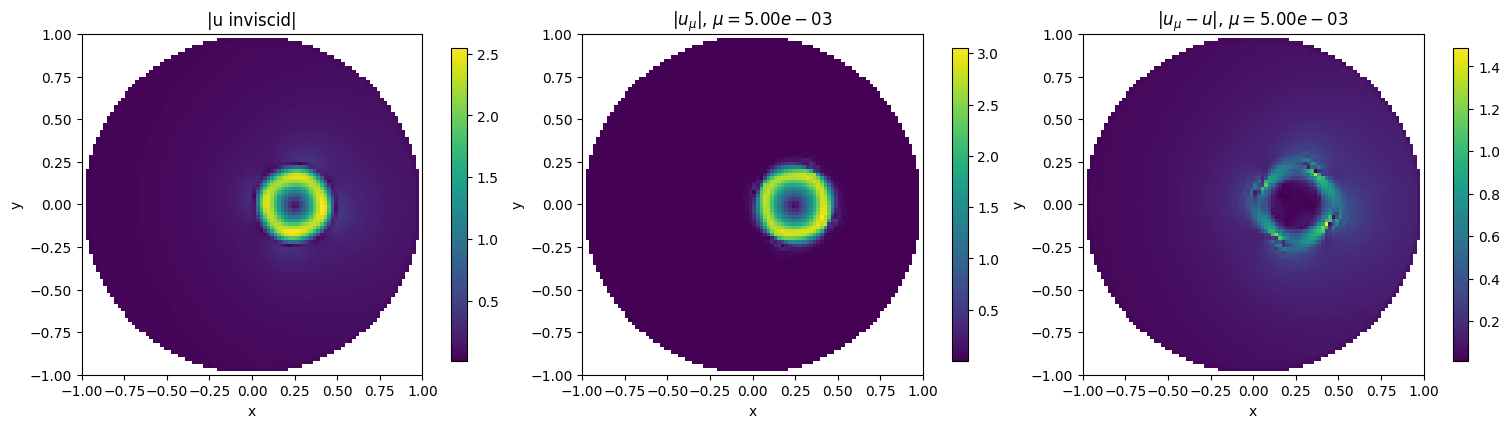

In [74]:
mu_smallest = float(min(u_mu_values.keys()))

u_mu_smallest = u_mu_values[mu_smallest]
print(f"Smallest available viscosity: mu = {mu_smallest:.4e}")

plot_vanishing_field_comparison(
    u_ref=u_inv_final,
    u_mu=u_mu_smallest,
    grid=grid,
    mu=mu_smallest,
)


In [75]:
print("=" * 100)
print("Targeted vanishing-viscosity summary")

mu_arr = table_vv["mu"]
err_abs_arr = table_vv["error_abs"]
err_rel_arr = table_vv["error_rel"]
div_arr = table_vv["divbu_l2"]
proj_arr = table_vv["projection_defect_after"]
res_arr = table_vv["projection_solver_residual"]
cfl_arr = table_vv["max_cfl_ratio"]

for i, mu in enumerate(mu_arr):
    print(f"mu = {mu:.4e}")
    print(f"  absolute weighted velocity error = {err_abs_arr[i]:.8e}")
    print(f"  relative weighted velocity error = {err_rel_arr[i]:.8e}")
    print(f"  final ||div(bu_mu)||_L2          = {div_arr[i]:.8e}")
    print(f"  final projection defect          = {proj_arr[i]:.8e}")
    print(f"  final projection solver residual = {res_arr[i]:.8e}")
    print(f"  max CFL ratio                    = {cfl_arr[i]:.8e}")
    print()

slope_abs = table_vv["slope_abs"][0]
slope_rel = table_vv["slope_rel"][0]

print(f"Fitted absolute-error slope = {slope_abs:.8e}")
print(f"Fitted relative-error slope = {slope_rel:.8e}")

print()
print("Formal reference slopes:")
for beta in cfg.beta_reference_values:
    print(f"  beta = {beta:.2f} -> slope = {(1.0-beta)/2.0:.4f}")

print("=" * 100)


Targeted vanishing-viscosity summary
mu = 1.0000e-02
  absolute weighted velocity error = 2.83597572e-01
  relative weighted velocity error = 3.84243300e-01
  final ||div(bu_mu)||_L2          = 1.01329790e-01
  final projection defect          = 1.01329790e-01
  final projection solver residual = 6.88629775e-10
  max CFL ratio                    = 7.93862954e-02

mu = 5.0000e-03
  absolute weighted velocity error = 3.05086901e-01
  relative weighted velocity error = 4.13358960e-01
  final ||div(bu_mu)||_L2          = 3.01478299e-01
  final projection defect          = 3.01478299e-01
  final projection solver residual = 1.81298774e-09
  max CFL ratio                    = 7.95174312e-02

Fitted absolute-error slope = -1.05375057e-01
Fitted relative-error slope = -1.05375057e-01

Formal reference slopes:
  beta = 0.00 -> slope = 0.5000
  beta = 0.50 -> slope = 0.2500


The vanishing-viscosity pipeline is operational. However, the measured error does not decrease as mu decreases in this quick run. The projection defect is comparable to the weighted velocity error, especially for mu=5e-3. Therefore, the fitted slope is not a verification of the theoretical rate and must be interpreted qualitatively.

## Interpretation of the vanishing-viscosity experiment

The table and plots above compare \(u_\mu\) and \(u\) using the weighted velocity norm

$$
\|u_\mu-u\|_{L^2_b}.
$$

For a rigorous numerical verification of the theoretical rate, the error should decrease as \(\mu\to0\), with a slope compatible with

$$
\mu^{(1-\beta)/2}.
$$

However, in this prototype, the measured error should be interpreted carefully.

The observed error is not purely the viscosity error. It contains

$$
\text{observed error}
=
\text{viscosity error}
+
\text{spatial error}
+
\text{time error}
+
\text{elliptic solver error}
+
\text{projection error}
+
\text{boundary geometry error}.
$$

The projection defect is especially important. If

$$
\|\operatorname{div}(bu_\mu)\|_{L^2}
$$

or the projection defect is comparable to

$$
\|u_\mu-u\|_{L^2_b},
$$
then the measured slope in \(\mu\) cannot be interpreted as the theoretical vanishing-viscosity rate.

In the current masked Cartesian prototype, the comparison is therefore qualitative. The code demonstrates the full numerical workflow, but a research-grade convergence study would require additional refinements.

## Improving the vanishing-viscosity study

To obtain a more meaningful convergence rate, one should perform a systematic error-budget study.

Possible improvements include:

1. **Spatial refinement**

   Repeat the experiment for several values of \(N\), for example

   $$
   N=64,\ 96,\ 128,\ 160.
   $$

2. **Time refinement**

   Reduce the time steps and check that the observed error is stable.

3. **Projection sensitivity**

   Test several values of

   $$
   \varepsilon_{\rm proj}.
   $$

   For example:

   $$
   \varepsilon_{\rm proj}=h^2,\quad h^3,\quad 0.
   $$

   This checks whether projection regularization dominates the error.

4. **More viscosity values**

   Use more than two or three values of \(\mu\), for example:

   $$
   \mu = 2\times10^{-2},\ 10^{-2},\ 5\times10^{-3},\ 2\times10^{-3}.
   $$

5. **Boundary-fitted method**

   Replace the masked Cartesian boundary by a boundary-fitted finite element or finite volume method.

6. **Implicit viscous solver**

   Treat the viscous operator implicitly to improve stability and accuracy for small \(\mu\).

7. **Consistent projection**

   Build a projection where the discrete gradient and divergence operators are adjoint in the weighted inner product.

Only after these numerical errors are controlled can the fitted slope be meaningfully compared with the theoretical rate.

## End of Part 4

The vanishing-viscosThe vanishing-viscosity comparison has been performed.
u_mu_smallest

Main objects created:

```python
u_mu_values
viscous_diagnostics
table_vv
